In [19]:
# ==============================================================================
# DATA CLEANING & STANDARDIZATION PIPELINE
# Project: An Explainable Machine Learning-Based Crop Yield Prediction and
#          Intelligent Decision Support System for Smart Agriculture.
# ==============================================================================
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import os
import io

# ------------------------------------------------------------------------------
# Configuration & File Paths
# ------------------------------------------------------------------------------
# Using the verbatim file names provided. Ensure these are uploaded to the Colab
# working directory (usually '/content/').
FILE_PATHS = {
    "Crop": "ML_Dataset_Featured/Crop_Featured.csv",
    "Climate": "ML_Dataset_Featured/Temperature_Featured.csv",
    "Soil": "ML_Dataset_Featured/Soil_Featured.csv",
    "Fertilizer": "ML_Dataset_Featured/Fertilizer_Featured.csv",
    "Pesticide": "ML_Dataset_Featured/Pesticide_Featured.csv",
    "Rainfall": "ML_Dataset_Featured/Rainfall_Featured.csv"
}

CLEAN_PATHS = {
    "Crop": "Crop_Production_Clean.csv",
    "Rainfall": "Rainfall_Featured.csv",
    "Temperature": "Temperature_Clean.csv",
    "Soil": "Soil_Clean.csv",
    "Fertilizer": "Fertilizer_Clean.csv",
    "Pesticide": "Pesticide_Clean.csv"
}

# Tracking dictionaries for the final report
report_data = {
    "Before": {},
    "After": {},
    "Issues": {},
    "Standardizations": {}
}

# ------------------------------------------------------------------------------
# Step 1: Load Every Dataset
# ------------------------------------------------------------------------------
print("--- STEP 1: LOADING DATASETS ---")
datasets = {}

for name, path in FILE_PATHS.items():
    if os.path.exists(path):
        try:
            df = pd.read_csv(path)

            if name == "Climate":
                climate_df = df.copy()

                # Identify common identifier columns (assuming these are always present)
                common_id_cols_keywords = ['station name', 'month', 'period', 'no. of years']
                common_id_cols = [c for c in climate_df.columns if any(kw in c.lower() for kw in common_id_cols_keywords)]

                # Identify temperature value columns dynamically, using 'and' for more robust matching
                temp_max_value_col = next((c for c in climate_df.columns if 'max' in c.lower() and 'temp' in c.lower()), None)
                temp_min_value_col = next((c for c in climate_df.columns if 'min' in c.lower() and 'temp' in c.lower()), None)

                # Construct Temperature DataFrame
                if temp_max_value_col and temp_min_value_col:
                    df_temperature = climate_df[common_id_cols + [temp_max_value_col, temp_min_value_col]].copy()
                    datasets["Temperature"] = df_temperature
                    report_data["Before"]["Temperature"] = df_temperature.shape[0]
                    print(f"\n✅ Successfully loaded and split: Temperature")
                    print(f"   Shape: {df_temperature.shape[0]} Rows × {df_temperature.shape[1]} Columns")
                    print(f"   Memory Usage: {df_temperature.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
                    print(df_temperature.describe(include='all'))
                    display(df_temperature.info())
                    print("   First 5 Rows:")
                    display(df_temperature.head())
                else:
                    print(f"❌ Could not find 'max' and 'temp' or 'min' and 'temp' columns in Climate data. Skipping Temperature dataset split.")
                    datasets["Temperature"] = pd.DataFrame() # Add empty dataframe to prevent KeyError later

            elif name == "Rainfall":
                rainfall_df = df.copy()

                # Identify common identifier columns (assuming these are always present)
                common_id_cols_keywords = ['station name', 'month', 'period', 'no. of years']
                common_id_cols = [c for c in rainfall_df.columns if any(kw in c.lower() for kw in common_id_cols_keywords)]

                # Identify rainfall value column dynamically
                rainfall_value_col = next((c for c in rainfall_df.columns
                                           if ('annual' in c.lower() and 'rainfall' in c.lower())
                                           or 'mean rainfall' in c.lower()
                                           or 'average_rainfall' in c.lower()
                                           or ('rainfall' in c.lower() and 'temp' not in c.lower())), None)

                if rainfall_value_col:
                    df_rainfall = rainfall_df[common_id_cols + [rainfall_value_col]].copy()
                    datasets["Rainfall"] = df_rainfall
                    report_data["Before"]["Rainfall"] = df_rainfall.shape[0]
                    print(f"\n✅ Successfully loaded and split: Rainfall")
                    print(f"   Shape: {df_rainfall.shape[0]} Rows × {df_rainfall.shape[1]} Columns")
                    print(f"   Memory Usage: {df_rainfall.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
                    print(df_rainfall.describe(include='all'))
                    display(df_rainfall.info())
                    print("   First 5 Rows:")
                    display(df_rainfall.head())
                else:
                    print(f"❌ Could not find a 'rainfall' column in Rainfall data. Skipping Rainfall dataset split.")
                    datasets["Rainfall"] = pd.DataFrame() # Add empty dataframe to prevent KeyError later

            else:
                datasets[name] = df
                report_data["Before"][name] = df.shape[0]

                print(f"\n✅ Successfully loaded: {name}")
                print(f"   Shape: {df.shape[0]} Rows × {df.shape[1]} Columns")
                print(f"   Memory Usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
                print(df.describe(include='all'))
                display(df.info())
                print("   First 5 Rows:")
                display(df.head())
        except Exception as e:
            print(f"❌ Error loading {name}: {e}")
    else:
        print(f"⚠️ File not found: {path}. Please ensure it is uploaded.")
# ------------------------------------------------------------------------------
# Step 2: Data Quality Assessment (Functions)
# ------------------------------------------------------------------------------
def assess_data_quality(df, name):
    print(f"\n--- Assessing Data Quality: {name} ---")

    # 1. Missing Values
    missing = df.isnull().sum()
    missing_pct = (missing / len(df)) * 100
    missing_df = pd.DataFrame({'Missing Values': missing, 'Percentage (%)': missing_pct})
    missing_df = missing_df[missing_df['Missing Values'] > 0]

    if not missing_df.empty:
        print("\nMissing Values Summary:")
        display(missing_df)
    else:
        print("\nNo Missing Values detected.")
    # 2. Duplicate Records
    duplicates = df.duplicated().sum()
    print(f"\nExact Duplicate Rows: {duplicates}")

    # 3. Invalid Values (Domain Specific)
    invalid_issues = []
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    string_cols = df.select_dtypes(include=['object']).columns

    # Check for negative values in specific domain metrics
    for col in numeric_cols:
        col_lower = col.lower()
        if any(keyword in col_lower for keyword in ['production', 'area', 'yield', 'rainfall', 'consumption']):
            negatives = (df[col] < 0).sum()
            if negatives > 0:
                invalid_issues.append(f"{col} has {negatives} negative values.")
        if 'ph level' in col_lower:
            invalid_ph = ((df[col] < 0) | (df[col] > 14)).sum()
            if invalid_ph > 0:
                invalid_issues.append(f"{col} has {invalid_ph} invalid pH values (outside 0-14).")

    # Check for empty strings or purely whitespace
    for col in string_cols:
        empty_strings = df[col].astype(str).str.strip().eq('').sum()
        if empty_strings > 0:
            invalid_issues.append(f"{col} has {empty_strings} empty or whitespace-only strings.")

    if invalid_issues:
        print("\nInvalid Values Detected:")
        for issue in invalid_issues:
            print(f" - {issue}")
    else:
        print("\nNo obvious invalid domain values detected.")

    report_data["Issues"][name] = invalid_issues
    return duplicates
# Run assessment
for name, df in datasets.items():
    assess_data_quality(df, name)

--- STEP 1: LOADING DATASETS ---

✅ Successfully loaded: Crop
   Shape: 246091 Rows × 14 Columns
   Memory Usage: 83.40 MB
           State_Name District_Name      Crop_Year  Season    Crop  \
count          246091        246091  246091.000000  246091  246091   
unique             33           646            NaN       6     124   
top     Uttar Pradesh       BIJAPUR            NaN  Kharif    Rice   
freq            33306           945            NaN   95951   15104   
mean              NaN           NaN    2005.643018     NaN     NaN   
std               NaN           NaN       4.952164     NaN     NaN   
min               NaN           NaN    1997.000000     NaN     NaN   
25%               NaN           NaN    2002.000000     NaN     NaN   
50%               NaN           NaN    2006.000000     NaN     NaN   
75%               NaN           NaN    2010.000000     NaN     NaN   
max               NaN           NaN    2015.000000     NaN     NaN   

                Area    Production  

None

   First 5 Rows:


,State_Name,District_Name,Crop_Year,Season,Crop,Area,Production,Yield,Log_Production,Farm_Size,Season_Encoded,Crop_Encoded,State_Name_Encoded,District_Name_Encoded
0,Andaman And Nicobar Islands,NICOBARS,2000,Kharif,Arecanut,1254.0,2000.0,1.594896,7.601402,Medium,1,2,0,427
1,Andaman And Nicobar Islands,NICOBARS,2000,Kharif,Other Kharif Pulses,2.0,1.0,0.500000,0.693147,Small,1,75,0,427
2,Andaman And Nicobar Islands,NICOBARS,2000,Kharif,Rice,102.0,321.0,3.147059,5.774552,Medium,1,98,0,427
3,Andaman And Nicobar Islands,NICOBARS,2000,Whole Year,Banana,176.0,641.0,3.642045,6.464588,Medium,4,7,0,427
4,Andaman And Nicobar Islands,NICOBARS,2000,Whole Year,Cashewnut,720.0,165.0,0.229167,5.111988,Medium,4,22,0,427



✅ Successfully loaded and split: Temperature
   Shape: 1332 Rows × 6 Columns
   Memory Usage: 0.25 MB
       Station Name    Month     Period  No. of Years  \
count          1332     1332       1332   1332.000000   
unique          111       12         46           NaN   
top             Abu  January  1901-2000           NaN   
freq             12      111        456           NaN   
mean            NaN      NaN        NaN     64.378378   
std             NaN      NaN        NaN     29.160162   
min             NaN      NaN        NaN      5.000000   
25%             NaN      NaN        NaN     43.000000   
50%             NaN      NaN        NaN     53.000000   
75%             NaN      NaN        NaN     98.000000   
max             NaN      NaN        NaN    100.000000   

        Mean Temperature in degree C - Maximum  \
count                              1332.000000   
unique                                     NaN   
top                                        NaN   
freq        

...


Exact Duplicate Rows: 0

No obvious invalid domain values detected.

--- Assessing Data Quality: Fertilizer ---

No Missing Values detected.

Exact Duplicate Rows: 0

No obvious invalid domain values detected.

--- Assessing Data Quality: Pesticide ---

Missing Values Summary:


C:\Users\karth\AppData\Local\Temp\ipykernel_36768\4098241562.py:150: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  string_cols = df.select_dtypes(include=['object']).columns
C:\Users\karth\AppData\Local\Temp\ipykernel_36768\4098241562.py:150: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/use

,Missing Values,Percentage (%)
Pesticide_Consumption,47,22.926829



Exact Duplicate Rows: 0

No obvious invalid domain values detected.

--- Assessing Data Quality: Rainfall ---

No Missing Values detected.

Exact Duplicate Rows: 0

No obvious invalid domain values detected.


C:\Users\karth\AppData\Local\Temp\ipykernel_36768\4098241562.py:150: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  string_cols = df.select_dtypes(include=['object']).columns
C:\Users\karth\AppData\Local\Temp\ipykernel_36768\4098241562.py:150: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/use

# EDA

EXPLORATORY DATA ANALYSIS (EDA BEFORE PREPROCESSING)


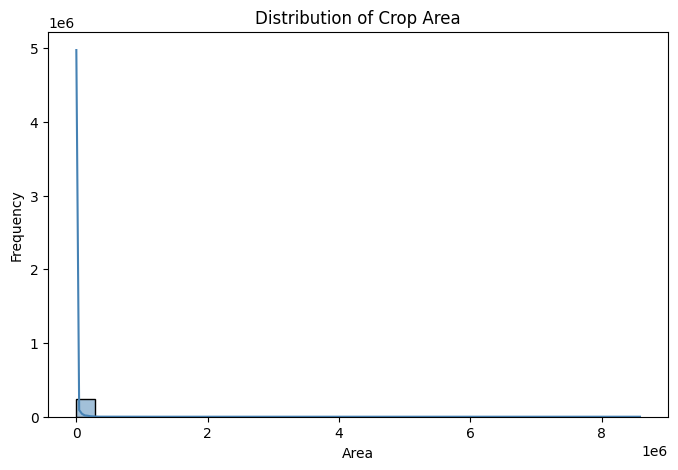

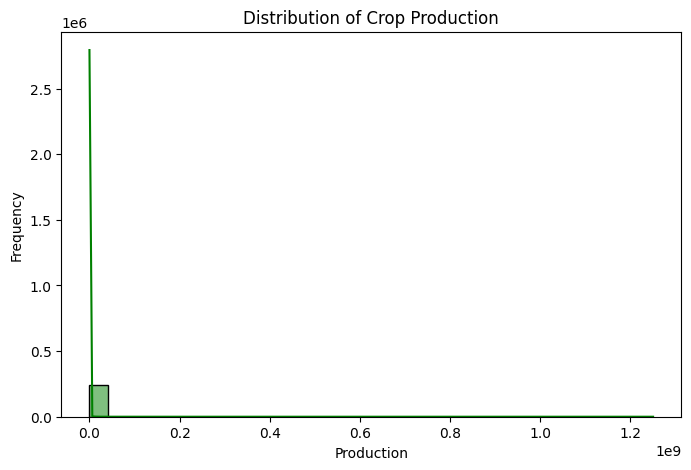

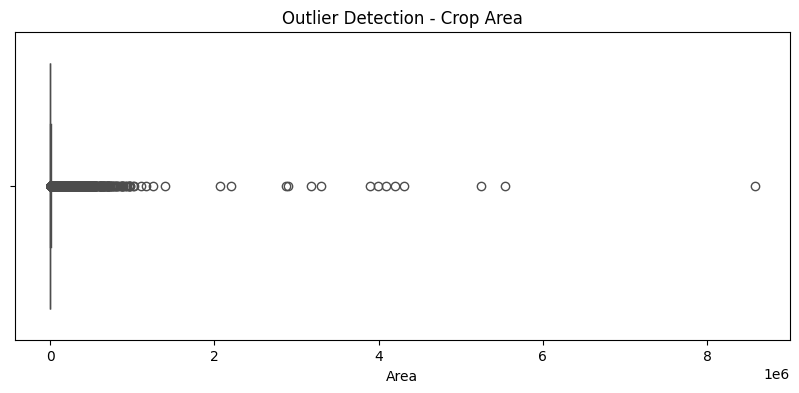

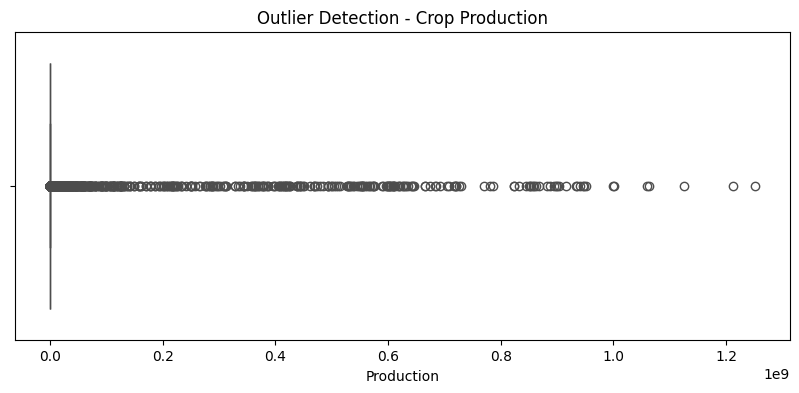

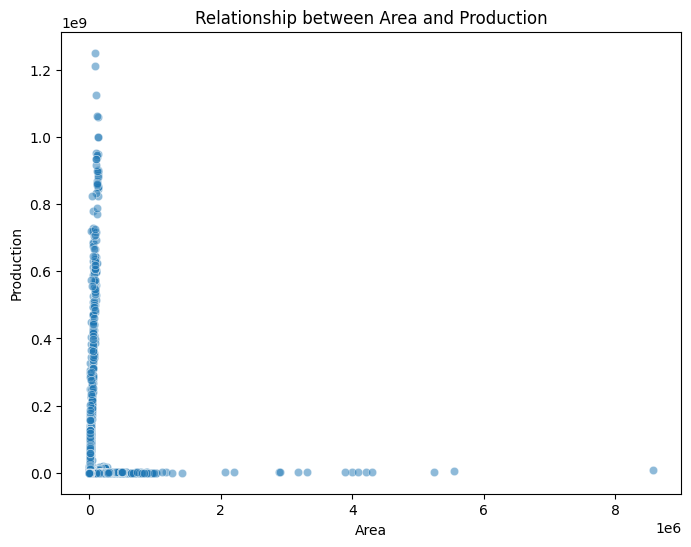

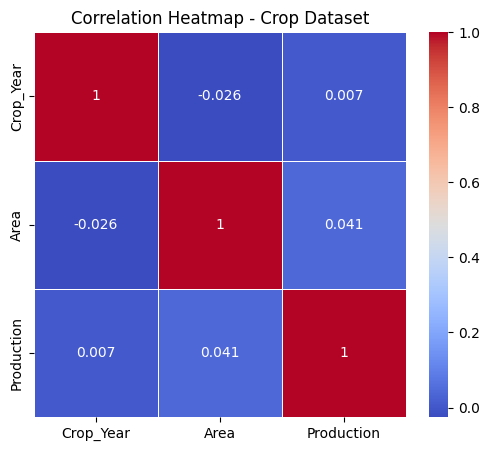

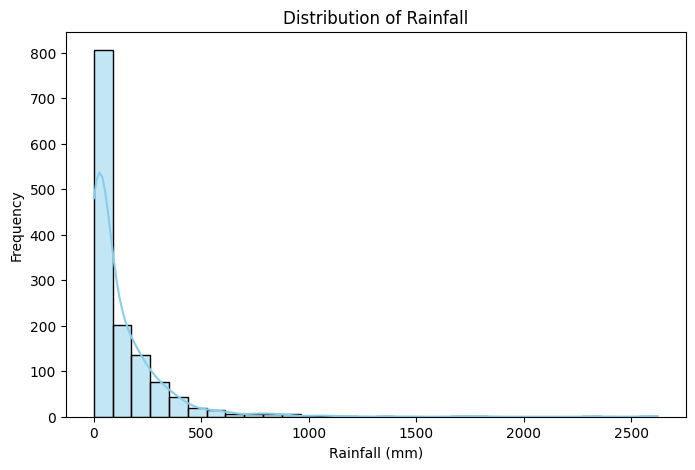

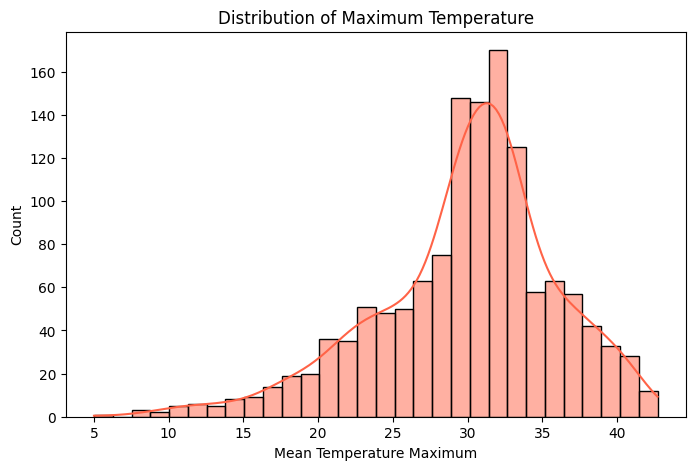

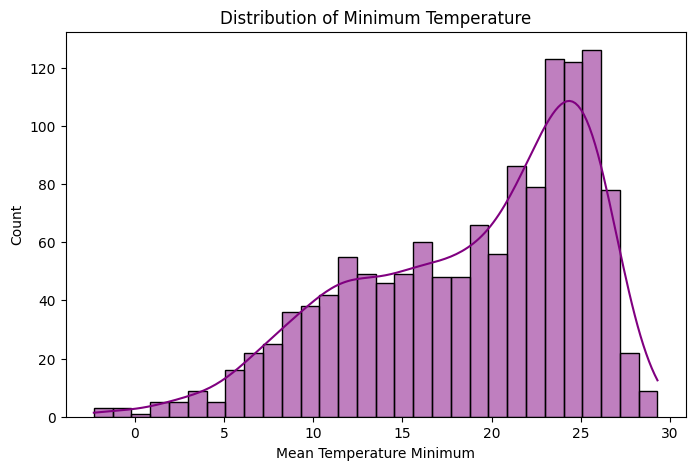

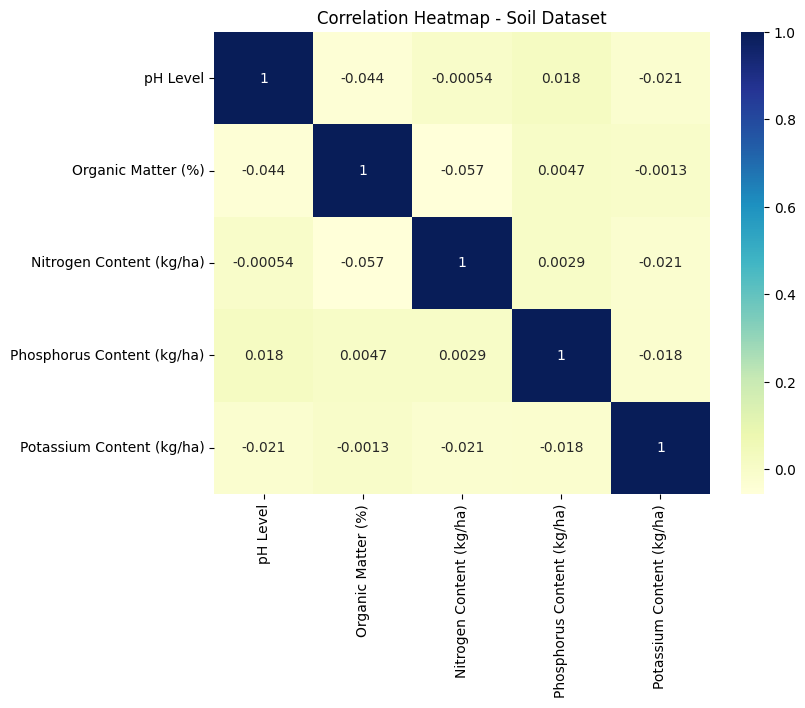

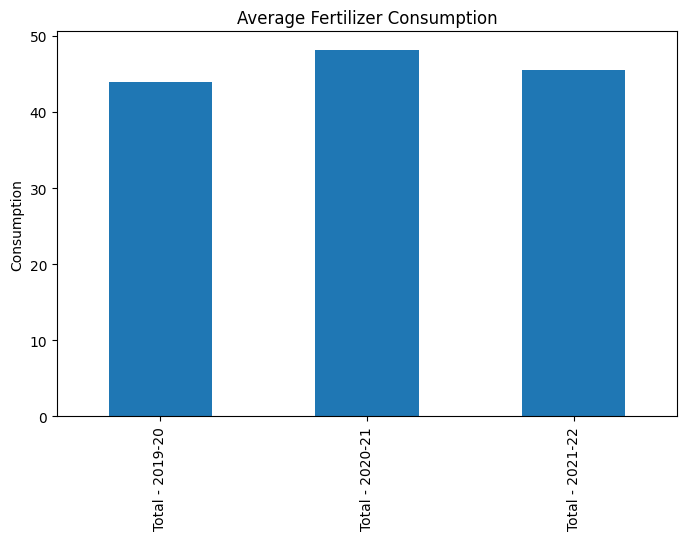

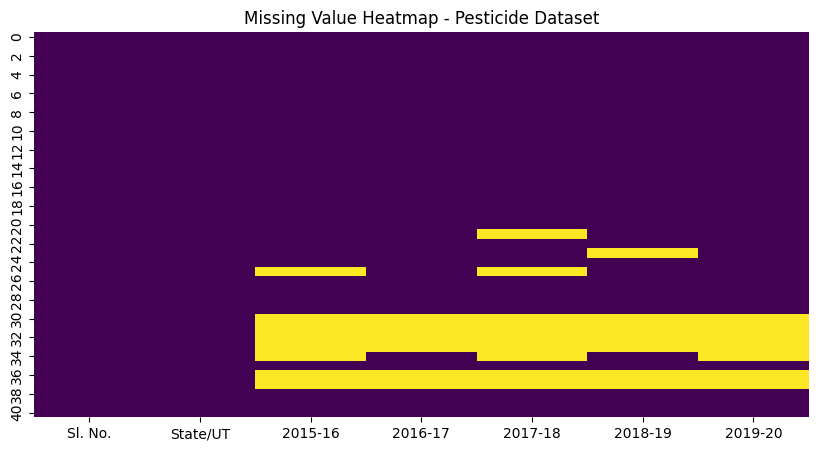


Dataset Summary


,Dataset,Rows,Columns,Missing Values,Duplicate Rows
0,Crop,246091,7,3730,0
1,Rainfall,1332,4,0,0
2,Temperature,1332,5,0,0
3,Soil,1000,7,0,0
4,Fertilizer,42,4,0,0
5,Pesticide,41,7,37,0


In [ ]:
# ==============================================================================
# STEP 3 : EXPLORATORY DATA ANALYSIS (EDA BEFORE PREPROCESSING)
# ==============================================================================
print("="*80)
print("EXPLORATORY DATA ANALYSIS (EDA BEFORE PREPROCESSING)")
print("="*80)
# ==============================================================================
# Crop Dataset
# ==============================================================================
crop = datasets["Crop"]
# ------------------------------------------------------------------------------
# Histogram - Area Distribution
# ------------------------------------------------------------------------------
plt.figure(figsize=(8,5))
sns.histplot(
    crop["Area"],
    bins=30,
    kde=True,
    color="steelblue"
)
plt.title("Distribution of Crop Area")
plt.xlabel("Area")
plt.ylabel("Frequency")

plt.show()

# ------------------------------------------------------------------------------
# Histogram - Production Distribution
# ------------------------------------------------------------------------------
plt.figure(figsize=(8,5))
sns.histplot(
    crop["Production"].dropna(),
    bins=30,
    kde=True,
    color="green"
)
plt.title("Distribution of Crop Production")
plt.xlabel("Production")
plt.ylabel("Frequency")
plt.show()
# ------------------------------------------------------------------------------
# Boxplot - Area
# ------------------------------------------------------------------------------
plt.figure(figsize=(10,4))
sns.boxplot(
    x=crop["Area"],
    color="orange"
)
plt.title("Outlier Detection - Crop Area")
plt.show()
# ------------------------------------------------------------------------------
# Boxplot - Production
# ------------------------------------------------------------------------------
plt.figure(figsize=(10,4))
sns.boxplot(
    x=crop["Production"],
    color="red"
)
plt.title("Outlier Detection - Crop Production")
plt.show()
# ------------------------------------------------------------------------------
# Scatter Plot
# ------------------------------------------------------------------------------
plt.figure(figsize=(8,6))
sns.scatterplot(
    data=crop,
    x="Area",
    y="Production",
    alpha=0.5
)
plt.title("Relationship between Area and Production")
plt.xlabel("Area")
plt.ylabel("Production")
plt.show()
# ------------------------------------------------------------------------------
# Correlation Heatmap
# ------------------------------------------------------------------------------
crop_numeric = crop.select_dtypes(include=np.number)
plt.figure(figsize=(6,5))
sns.heatmap(
    crop_numeric.corr(),
    annot=True,
    cmap="coolwarm",
    linewidths=0.5
)
plt.title("Correlation Heatmap - Crop Dataset")
plt.show()
# ==============================================================================
# Rainfall Dataset
# ==============================================================================
rainfall = datasets["Rainfall"]
plt.figure(figsize=(8,5))
sns.histplot(
    rainfall["Mean Rainfall in mm"],
    bins=30,
    kde=True,
    color="skyblue"
)
plt.title("Distribution of Rainfall")
plt.xlabel("Rainfall (mm)")
plt.ylabel("Frequency")
plt.show()
# ==============================================================================
# Temperature Dataset
# ==============================================================================
temperature = datasets["Temperature"]
plt.figure(figsize=(8,5))
sns.histplot(
    temperature["Mean Temperature Maximum"],
    bins=30,
    kde=True,
    color="tomato"
)
plt.title("Distribution of Maximum Temperature")
plt.show()
plt.figure(figsize=(8,5))
sns.histplot(
    temperature["Mean Temperature Minimum"],
    bins=30,
    kde=True,
    color="purple"
)
plt.title("Distribution of Minimum Temperature")
plt.show()
# ==============================================================================
# Soil Dataset
# ==============================================================================
soil = datasets["Soil"]
soil_numeric = soil.select_dtypes(include=np.number)
plt.figure(figsize=(8,6))
sns.heatmap(
    soil_numeric.corr(),
    annot=True,
    cmap="YlGnBu"
)
plt.title("Correlation Heatmap - Soil Dataset")
plt.show()
# ==============================================================================
# Fertilizer Dataset
# ==============================================================================
fertilizer = datasets["Fertilizer"]
fert_numeric = fertilizer.select_dtypes(include=np.number)
plt.figure(figsize=(8,5))
fert_numeric.mean().plot(
    kind="bar"
)
plt.title("Average Fertilizer Consumption")
plt.ylabel("Consumption")
plt.show()
# ==============================================================================
# Pesticide Dataset
# ==============================================================================
pesticide = datasets["Pesticide"]
plt.figure(figsize=(10,5))
sns.heatmap(
    pesticide.isnull(),
    cmap="viridis",
    cbar=False
)
plt.title("Missing Value Heatmap - Pesticide Dataset")
plt.show()
# ==============================================================================
# Dataset Summary
# ==============================================================================
summary = []
for name, df in datasets.items():
    summary.append({
        "Dataset": name,
        "Rows": df.shape[0],
        "Columns": df.shape[1],
        "Missing Values": int(df.isnull().sum().sum()),
        "Duplicate Rows": int(df.duplicated().sum())
    })
summary = pd.DataFrame(summary)
print("\nDataset Summary")
display(summary)

# Model Training and Evaluation

In [7]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder
import joblib
print("🚀 PART 3 : LOAD & MERGE DATASETS (Rainfall excluded) — STARTED")
print("=" * 60)


FILE_PATHS = {
    "Crop": "ML_Dataset_Featured/Crop_Featured.csv",
    "Temperature": "ML_Dataset_Featured/Temperature_Featured.csv",
    "Soil": "ML_Dataset_Featured/Soil_Featured.csv",
    "Fertilizer": "ML_Dataset_Featured/Fertilizer_Featured.csv",
    "Pesticide": "ML_Dataset_Featured/Pesticide_Featured.csv"
}

# -------------------------------------------------
# 3.1 LOAD RAW FILES
# -------------------------------------------------
crop_df       = pd.read_csv(FILE_PATHS["Crop"])
temp_df       = pd.read_csv(FILE_PATHS["Temperature"])
soil_df       = pd.read_csv(FILE_PATHS["Soil"]) # Corrected: s_df to soil_df
fert_df       = pd.read_csv(FILE_PATHS["Fertilizer"])
pest_df       = pd.read_csv(FILE_PATHS["Pesticide"])

print(f"✅ Crop:        {crop_df.shape}")
print(f"✅ Temperature: {temp_df.shape}")
print(f"✅ Soil:        {soil_df.shape}")
print(f"✅ Fertilizer:  {fert_df.shape}")
print(f"✅ Pesticide:   {pest_df.shape}")

STATE_NAME_ALIASES = {
    "chattishgarh": "chhattisgarh",
    "orissa": "odisha",
    "tamilnadu": "tamil nadu",
    "andaman and nicobar islands": "andaman and nicobar islands",
    "dadra and nagar haveli": "dadra and nagar haveli",
    "daman and diu": "daman and diu",
    "lakshadweep": "lakshadweep",
    "puducherry": "puducherry"
}

def normalize_name(s):
    """Lowercase + strip, so 'Andhra Pradesh' matches 'ANDHRA PRADESH ' etc."""
    key = str(s).strip().lower().replace('  ', ' ')
    return STATE_NAME_ALIASES.get(key, key)

# -------------------------------------------------
# 3.2 BASE ENCODING ON CROP DATA (unchanged from earlier parts)
# -------------------------------------------------
for col in ["Season", "Crop", "State_Name", "District_Name"]:
    le = LabelEncoder()
    crop_df[f"{col}_Encoded"] = le.fit_transform(crop_df[col].astype(str))

crop_df["State_Key"] = crop_df["State_Name"].apply(normalize_name)
crop_df["District_Key"] = crop_df["District_Name"].apply(normalize_name)

# -------------------------------------------------
# 3.3 TEMPERATURE — aggregate station-level normals, merge on State ≈ Station
# -------------------------------------------------
# NOTE: This file is 1901-2000 climate normals per station/month, not per crop-year.
# We collapse it to ONE average temperature profile per station, then match that
# station name against State_Name. If your stations don't correspond 1:1 to
# states, replace this block with a proper station->state lookup table.
temp_agg = (
    temp_df.groupby("Station Name")
    .agg(
        Average_Temperature=("Mean Temperature in degree C - Maximum", "mean"),
        Min_Temp_Mean=("Mean Temperature  in degree C - Minimum", "mean"), # Corrected: one space
    )
    .reset_index()
)
temp_agg["Temperature_Range"] = temp_agg["Average_Temperature"] - temp_agg["Min_Temp_Mean"]
temp_agg["State_Key"] = temp_agg["Station Name"].apply(normalize_name)
temp_agg = temp_agg[["State_Key", "Average_Temperature", "Temperature_Range"]]

crop_df = crop_df.merge(temp_agg, on="State_Key", how="left")
print(f"✅ Temperature merged | matched rows: {crop_df['Average_Temperature'].notna().sum():,} / {len(crop_df):,}")

# -------------------------------------------------
# 3.4 SOIL — merge on District
# -------------------------------------------------
# The soil file contains repeated samples per district. Aggregate to one row per district.
# FIX: soil_df never had a "District_Key" column built on it (only crop_df did,
# in 3.2 above) -- that's what caused KeyError: 'District_Key'. Build it here
# the same way State_Key is built for Temperature/Pesticide below, using the
# same normalize_name() so it lines up with crop_df["District_Key"].
soil_district_col = next((c for c in soil_df.columns if "district" in c.lower()), None)
if soil_district_col is None:
    raise KeyError("Could not find a District column in soil_df to build District_Key from.")
soil_df["District_Key"] = soil_df[soil_district_col].apply(normalize_name)

# FIX: Soil_Featured.csv only has the raw "Soil Type" text column (e.g. "Sandy",
# "Clay"), not "Soil_Type_Encoded" -- the aggregation below expects the encoded
# version. Encode it here the same way Season/Crop/State_Name/District_Name were
# label-encoded on crop_df in 3.2 above, so "Soil_Type_Encoded" actually exists
# before the groupby/agg tries to use it.
if "Soil_Type_Encoded" not in soil_df.columns:
    soil_type_col = next((c for c in soil_df.columns if "soil type" in c.lower() or "soil_type" in c.lower()), None)
    if soil_type_col is None:
        raise KeyError("Could not find a Soil Type column in soil_df to encode.")
    le_soil = LabelEncoder()
    soil_df["Soil_Type_Encoded"] = le_soil.fit_transform(soil_df[soil_type_col].astype(str))

soil_df = (
    soil_df.groupby("District_Key", as_index=False)
    .agg({
        "pH Level": "mean",
        "Organic Matter (%)": "mean",
        "Nitrogen Content (kg/ha)": "mean",
        "Potassium Content (kg/ha)": "mean",
        "Soil_Fertility_Index": "mean",
        "Soil_Type_Encoded": lambda x: x.mode().iloc[0] if not x.mode().empty else x.iloc[0]
    })
)

soil_cols = [
    "District_Key", "pH Level", "Organic Matter (%)", "Nitrogen Content (kg/ha)",
    "Potassium Content (kg/ha)",
    "Soil_Fertility_Index", "Soil_Type_Encoded"
]
crop_df = crop_df.merge(soil_df[soil_cols], on="District_Key", how="left")
print(f"✅ Soil merged | matched rows: {crop_df['pH Level'].notna().sum():,} / {len(crop_df):,}")
# -------------------------------------------------
# 3.5 FERTILIZER — merge on State, average across the 3 available years
# -------------------------------------------------
# NOTE: only 2019-20/2020-21/2021-22 are available; crop years go back to 1997,
# so this applies the same recent-years average fertilizer figure to every
# crop year for a given state (a known limitation of the source data, not
# something this fix changes).
# FIX: this section's actual merge code was missing -- the "3.5 FERTILIZER"
# header was duplicated and execution fell straight into the Pesticide merge
# below, so crop_df never got a "Fertilizer_Consumption" column at all.
fert_year_cols = [c for c in fert_df.columns if "20" in c]
if not fert_year_cols:
    raise KeyError("Could not find any fertilizer year columns (e.g. 'Total - 2019-20') in fert_df.")
fert_df["Fertilizer_Consumption"] = fert_df[fert_year_cols].mean(axis=1)
fert_df["State_Key"] = fert_df["State/UT"].apply(normalize_name)

fert_df = fert_df.groupby("State_Key", as_index=False)["Fertilizer_Consumption"].mean()

crop_df = crop_df.merge(fert_df[["State_Key", "Fertilizer_Consumption"]], on="State_Key", how="left")
print(f"✅ Fertilizer merged | matched rows: {crop_df['Fertilizer_Consumption'].notna().sum():,} / {len(crop_df):,}")

# -------------------------------------------------
# 3.6 PESTICIDE — merge on State
# -------------------------------------------------
pest_df["Pesticide_Consumption"] = pd.to_numeric(pest_df["Pesticide_Consumption"], errors="coerce")
pest_df["State_Key"] = pest_df["State/UT"].apply(normalize_name)

pest_df = pest_df.groupby("State_Key", as_index=False)["Pesticide_Consumption"].mean()

crop_df = crop_df.merge(pest_df[["State_Key", "Pesticide_Consumption"]], on="State_Key", how="left")
print(f"✅ Pesticide merged | matched rows: {crop_df['Pesticide_Consumption'].notna().sum():,} / {len(crop_df):,}")

# -------------------------------------------------
# 3.7 TARGET + FINAL EXTRA FEATURES
# -------------------------------------------------
crop_df["Yield"] = crop_df["Production"] / crop_df["Area"].replace(0, np.nan)

crop_df["Climate_Index"] = crop_df["Average_Temperature"] / crop_df["Temperature_Range"].replace(0, np.nan)
crop_df["Input_Intensity"] = crop_df["Fertilizer_Consumption"] + crop_df["Pesticide_Consumption"]
crop_df["Agricultural_Intensity"] = crop_df["Input_Intensity"] * crop_df["Soil_Fertility_Index"]

# -------------------------------------------------
# 3.8 IMPUTE MISSING VALUES BEFORE MODELING
# -------------------------------------------------
print("\n--- Imputing missing values for model training ---")
imputed_count = 0

# Impute numeric columns with their median
numeric_cols_to_impute = [
    "pH Level", "Organic Matter (%)", "Nitrogen Content (kg/ha)",
    "Potassium Content (kg/ha)",
    "Soil_Fertility_Index", "Average_Temperature", "Temperature_Range",
    "Fertilizer_Consumption", "Pesticide_Consumption",
    "Climate_Index", "Input_Intensity", "Agricultural_Intensity"
]

for col in numeric_cols_to_impute:
    if col in crop_df.columns and crop_df[col].isnull().any():
        median_val = crop_df[col].median()
        crop_df[col] = crop_df[col].fillna(median_val)
        imputed_count += 1
        print(f"  ✅ Imputed '{col}' with median: {median_val:.2f}")

# Impute 'Soil_Type_Encoded' (categorical) with mode
if "Soil_Type_Encoded" in crop_df.columns and crop_df["Soil_Type_Encoded"].isnull().any():
    mode_val = crop_df["Soil_Type_Encoded"].mode()[0]
    crop_df["Soil_Type_Encoded"] = crop_df["Soil_Type_Encoded"].fillna(mode_val)
    imputed_count += 1
    print(f"  ✅ Imputed 'Soil_Type_Encoded' with mode: {mode_val}")

if imputed_count == 0:
    print("  No missing values found in key features for imputation.")
else:
    print(f"--- Imputation complete. Total columns imputed: {imputed_count} ---")

final_df = crop_df.copy()
final_df.to_csv("Merged_Crop_Dataset.csv", index=False)
print(f"\n💾 Saved Merged_Crop_Dataset.csv | Final shape: {final_df.shape}")
print("✅ PART 3 : MERGE — COMPLETE")
imputed_count += 1

# ==============================================================================
# PART 4: STAGED MULTI-MODEL TRAINING & COMPARISON (No Rainfall)
# ==============================================================================
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from catboost import CatBoostRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("\n🚀 PART 4 : STAGED MULTI-MODEL TRAINING — STARTED")
print("=" * 60)

TARGET = "Yield"

CROP_FEATURES = [
    "Crop_Year", "Area", "Season_Encoded", "Crop_Encoded",
    "State_Name_Encoded", "District_Name_Encoded"
]
SOIL_FEATURES = [
    "pH Level", "Organic Matter (%)", "Nitrogen Content (kg/ha)",
    "Potassium Content (kg/ha)",
    "Soil_Fertility_Index", "Soil_Type_Encoded"
]
TEMPERATURE_FEATURES = ["Average_Temperature", "Temperature_Range"]
FERTILIZER_FEATURES = ["Fertilizer_Consumption"]
PESTICIDE_FEATURES = ["Pesticide_Consumption"]
FINAL_EXTRA_FEATURES = [
    "Fertilizer_Consumption", "Pesticide_Consumption",
    "Climate_Index", "Input_Intensity", "Agricultural_Intensity"
]

ALL_POSSIBLE_FEATURES = list(dict.fromkeys(
    CROP_FEATURES + SOIL_FEATURES + TEMPERATURE_FEATURES
    + FERTILIZER_FEATURES + PESTICIDE_FEATURES + FINAL_EXTRA_FEATURES
))

model_ready_df = final_df.dropna(subset=ALL_POSSIBLE_FEATURES + [TARGET]).reset_index(drop=True)
print(f"✅ Model-ready rows after dropping NaNs across all stage features: {len(model_ready_df):,}")

X_full = model_ready_df[ALL_POSSIBLE_FEATURES]
y_full = model_ready_df[TARGET]

X_train_full, X_test_full, y_train, y_test = train_test_split(
    X_full, y_full, test_size=0.2, random_state=42
)
print(f"✅ ONE-TIME train/test split | Train: {X_train_full.shape[0]:,} | Test: {X_test_full.shape[0]:,}")

STAGES = {
    "Stage 1: Crop (Baseline)":            CROP_FEATURES,
    "Stage 2: Crop + Soil":                CROP_FEATURES + SOIL_FEATURES,
    "Stage 3: Crop + Temperature":          CROP_FEATURES + TEMPERATURE_FEATURES,
    "Stage 4: Crop + Fertilizer":           CROP_FEATURES + FERTILIZER_FEATURES,
    "Stage 5: Crop + Pesticide":            CROP_FEATURES + PESTICIDE_FEATURES,
    "Stage 6: Crop + Soil + Temperature":   CROP_FEATURES + SOIL_FEATURES + TEMPERATURE_FEATURES,
    "Stage 7: Final Dataset (All)":         CROP_FEATURES + SOIL_FEATURES + TEMPERATURE_FEATURES + FINAL_EXTRA_FEATURES,
}

def get_models():
    return {
        "CatBoost": CatBoostRegressor(iterations=300, learning_rate=0.05, depth=6,
                                       random_state=42, verbose=False),
    }

results = []

for stage_name, feature_cols in STAGES.items():
    print("\n" + "=" * 60)
    print(f"📊 {stage_name}  |  Features: {feature_cols}")
    print("=" * 60)

    X_train = X_train_full[feature_cols]
    X_test = X_test_full[feature_cols]

    # for model_name, model in get_models().items():
    model = CatBoostRegressor(iterations=300, learning_rate=0.05, depth=6,
                                    random_state=42, verbose=False)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    results.append({"Stage": stage_name, "Model": list(get_models().keys())[0] ,"MAE": mae, "MSE": mse, "RMSE": rmse, "R2": r2})
    print(f"✅ {list(get_models().keys())[0]:12s} | MAE: {mae:.4f} | MSE: {mse:.4f} | RMSE: {rmse:.4f} | R²: {r2:.4f}")
    
best_model = model
results_df = pd.DataFrame(results)

comparison_table = results_df.pivot(index="Stage", columns="Model", values="R2")
comparison_table = comparison_table.reindex(list(STAGES.keys()))[["CatBoost"]]

print("\n" + "=" * 60)
print("FINAL STAGE-WISE R² COMPARISON TABLE")
print("=" * 60)
print(comparison_table.round(4))

results_df.to_csv("Staged_Model_Results_Full.csv", index=False)
comparison_table.to_csv("Staged_Model_R2_Comparison.csv")
print("\n💾 Saved: Staged_Model_Results_Full.csv")
print("💾 Saved: Staged_Model_R2_Comparison.csv")
print("\n✅ PART 4 : STAGED MULTI-MODEL TRAINING — COMPLETE")


comparison_table = comparison_table.reindex(list(STAGES.keys()))[["CatBoost"]]



print("\n" + "=" * 60)

print("\n" + "=" * 60)
print("FINAL STAGE-WISE R² COMPARISON TABLE")
print("\n✅ PART 4 : STAGED MULTI-MODEL TRAINING — COMPLETE")

print("FINAL STAGE-WISE R² COMPARISON TABLE")
print("=" * 60)
print("\n✅ PART 4 : STAGED MULTI-MODEL TRAINING — COMPLETE")

print("=" * 60)
print(comparison_table.round(4))
print("💾 Saved: Staged_Model_R2_Comparison.csv")

print(comparison_table.round(4))
print("💾 Saved: Staged_Model_R2_Comparison.csv")
TARGET = "Yield"
FEATURES = [
    "Crop_Year", "Area", "Season_Encoded", "Crop_Encoded",
    "State_Name_Encoded", "District_Name_Encoded",
    "pH Level", "Organic Matter (%)", "Nitrogen Content (kg/ha)",
    "Potassium Content (kg/ha)", "Soil_Fertility_Index", "Soil_Type_Encoded",
    "Fertilizer_Consumption", "Pesticide_Consumption",
    "Annual_Rainfall", "Average_Rainfall", "Rainy_Months_Count",
    "Average_Temperature", "Temperature_Range",
    "Weather_Index", "Climate_Index", "Input_Intensity", "Agricultural_Intensity",
]

results_df.to_csv("Staged_Model_cat_Results_Full- version 2.csv", index=False)
print("\n💾 Saved: Staged_Model_cat_Results_Full- version 2.csv")

results_df.to_csv("Staged_Model_cat_Results_Full- version 2.csv", index=False)
# comparison_table.to_csv("Staged_Model_R2_Comparison.csv")
# print("\n💾 Saved: Staged_Model_Results_Full.csv")
# comparison_table.to_csv("Staged_Model_R2_Comparison.csv")
# -------------------------------------------------
# 5. SAVE THE MODEL (+ everything needed to reuse it later)
# -------------------------------------------------
best_model.save_model("best_catboost_model_v2.cbm")          # CatBoost's native format (recommended)
joblib.dump(best_model, "best_catboost_model_v2.joblib")      # generic sklearn-style pickle, optional
joblib.dump(le_soil, "soil_type_label_encoder_v2.joblib")     # needed to encode Soil Type at inference time
joblib.dump(FEATURES, "model_feature_list_v2.joblib")         # needed to build inputs in the right column order

print("💾 Saved: best_catboost_model.cbm")
print("💾 Saved: best_catboost_model.joblib")
print("💾 Saved: soil_type_label_encoder.joblib")
print("💾 Saved: model_feature_list.joblib")

🚀 PART 3 : LOAD & MERGE DATASETS (Rainfall excluded) — STARTED
✅ Crop:        (246091, 14)
✅ Temperature: (1332, 8)
✅ Soil:        (1000, 7)
✅ Fertilizer:  (42, 4)
✅ Pesticide:   (205, 3)
✅ Temperature merged | matched rows: 90 / 246,091
✅ Soil merged | matched rows: 3,593 / 246,091
✅ Fertilizer merged | matched rows: 241,195 / 246,091
✅ Pesticide merged | matched rows: 214,728 / 246,091

--- Imputing missing values for model training ---
  ✅ Imputed 'pH Level' with median: 7.49
  ✅ Imputed 'Organic Matter (%)' with median: 2.00
  ✅ Imputed 'Nitrogen Content (kg/ha)' with median: 29.79
  ✅ Imputed 'Potassium Content (kg/ha)' with median: 39.96
  ✅ Imputed 'Soil_Fertility_Index' with median: 34.90
  ✅ Imputed 'Average_Temperature' with median: 30.38
  ✅ Imputed 'Temperature_Range' with median: 13.82
  ✅ Imputed 'Fertilizer_Consumption' with median: 37.21
  ✅ Imputed 'Pesticide_Consumption' with median: 1755.40
  ✅ Imputed 'Climate_Index' with median: 2.20
  ✅ Imputed 'Input_Intensity' w

# Standardization and cleaning

In [ ]:
# ------------------------------------------------------------------------------
# Step 3 & 4: Standardization and Cleaning
# ------------------------------------------------------------------------------
print("\n--- STEP 3 & 4: STANDARDIZATION & CLEANING ---")

def standardize_and_clean(df, name):
    print(f"Processing: {name}...")
    df_clean = df.copy()
    actions_taken = []

    # 1. Remove exact duplicates
    initial_rows = len(df_clean)
    df_clean.drop_duplicates(inplace=True)
    if initial_rows - len(df_clean) > 0:
        actions_taken.append(f"Dropped {initial_rows - len(df_clean)} duplicate rows.")

    # 2. Standardize Categorical Text
    string_cols = df_clean.select_dtypes(include=['object']).columns

    for col in string_cols:
        col_name = col.lower()

        # Standardize States
        if 'state' in col_name or 'ut' in col_name:
            df_clean[col] = df_clean[col].astype(str).str.strip().str.title()
            df_clean[col] = df_clean[col].replace({'Tamilnadu': 'Tamil Nadu'})
            actions_taken.append(f"Standardized State names in column '{col}' to Title Case.")

        # Standardize Districts
        elif 'district' in col_name:
            df_clean[col] = df_clean[col].astype(str).str.strip().str.upper()
            df_clean[col] = df_clean[col].str.replace('[^A-Z0-9]', '', regex=True)
            actions_taken.append(f"Standardized District names in column '{col}' to UPPERCASE and removed special characters.")

        # Standardize Crops
        elif 'crop' in col_name:
            df_clean[col] = df_clean[col].astype(str).str.strip().str.title()
            actions_taken.append(f"Standardized Crop names in column '{col}' to Title Case.")

        # Standardize Seasons
        elif 'season' in col_name:
            df_clean[col] = df_clean[col].astype(str).str.strip().str.title()
            actions_taken.append(f"Standardized Season names in column '{col}' to Title Case.")

        # General whitespace cleanup for other text columns
        else:
            df_clean[col] = df_clean[col].astype(str).str.strip()

    # 3. Handle Invalid Numeric Values (Negatives in area/production)
    numeric_cols = df_clean.select_dtypes(include=[np.number]).columns
    for col in numeric_cols:
        col_lower = col.lower()
        if any(keyword in col_lower for keyword in ['production', 'area', 'rainfall', 'consumption']):
            # Convert negative anomalies to NaN for imputation
            neg_mask = df_clean[col] < 0
            if neg_mask.sum() > 0:
                df_clean.loc[neg_mask, col] = np.nan
                actions_taken.append(f"Replaced {neg_mask.sum()} negative values in '{col}' with NaN.")

        if 'ph' in col_lower:
            invalid_ph = (df_clean[col] < 0) | (df_clean[col] > 14)
            if invalid_ph.sum() > 0:
                df_clean.loc[invalid_ph, col] = np.nan
                actions_taken.append(f"Replaced {invalid_ph.sum()} invalid pH values in '{col}' with NaN.")

    # 4. Handle Missing Values
    for col in df_clean.columns:
        missing_count = df_clean[col].isnull().sum()
        if missing_count > 0:
            missing_pct = missing_count / len(df_clean)

            # If missing > 60%, log it but keep it (instructed to keep as much data as possible)
            if missing_pct > 0.60:
                actions_taken.append(f"Warning: Column '{col}' has {missing_pct:.1%} missing data. Left as NaN to avoid biased imputation.")

            # Numeric imputation (Median for skewed agriculture data)
            elif pd.api.types.is_numeric_dtype(df_clean[col]):
                median_val = df_clean[col].median()
                df_clean[col].fillna(median_val, inplace=True)
                actions_taken.append(f"Imputed {missing_count} missing values in '{col}' with median ({median_val:.2f}).")

            # Categorical imputation (Mode)
            else:
                mode_val = df_clean[col].mode()[0]
                df_clean[col].fillna(mode_val, inplace=True)
                actions_taken.append(f"Imputed {missing_count} missing values in '{col}' with mode ('{mode_val}').")

    report_data["Standardizations"][name] = actions_taken
    return df_clean

cleaned_datasets = {}
for name, df in datasets.items():
    if not df.empty: # Only process if dataframe is not empty
        cleaned_datasets[name] = standardize_and_clean(df, name)
        report_data["After"][name] = len(cleaned_datasets[name])
    else:
        print(f"Skipping cleaning for empty dataset: {name}")
        cleaned_datasets[name] = pd.DataFrame() # Ensure an empty dataframe is present in cleaned_datasets
        report_data["After"][name] = 0 # Update after count to 0 for empty datasets

# ------------------------------------------------------------------------------
# Step 5: Validation
# ------------------------------------------------------------------------------
print("\n--- STEP 5: VALIDATION (Before vs After) ---")

for name in datasets.keys():
    print(f"\nDataset: {name}")
    print(f"Rows Before: {report_data['Before'].get(name, 0)} | Rows After: {report_data['After'].get(name, 0)}")

    # Ensure dataframes exist before calculating missing and duplicates
    if name in datasets and not datasets[name].empty:
        missing_before = datasets[name].isnull().sum().sum()
        duplicates_before = datasets[name].duplicated().sum()
    else:
        missing_before = 0
        duplicates_before = 0

    if name in cleaned_datasets and not cleaned_datasets[name].empty:
        missing_after = cleaned_datasets[name].isnull().sum().sum()
        duplicates_after = cleaned_datasets[name].duplicated().sum()
    else:
        missing_after = 0
        duplicates_after = 0

    print(f"Total Missing Values: {missing_before} -> {missing_after}")
    print(f"Total Duplicates: {duplicates_before} -> {duplicates_after}")

# ------------------------------------------------------------------------------
# Step 6: Save Outputs
# ------------------------------------------------------------------------------
print("\n--- STEP 6: SAVING CLEANED DATASETS ---")

for name, df_clean in cleaned_datasets.items():
    if not df_clean.empty:
        out_path = CLEAN_PATHS[name]
        df_clean.to_csv(out_path, index=False)
        print(f"✅ Saved cleaned dataset to: {out_path}")
    else:
        print(f"Skipping saving for empty dataset: {name}")

# ------------------------------------------------------------------------------
# Step 7: Generate Professional Markdown Report
# ------------------------------------------------------------------------------
print("\n--- STEP 7: GENERATING REPORT ---")

report_content = f"""# Data Cleaning & Standardization Report\n**Project:** An Explainable Machine Learning-Based Crop Yield Prediction and Intelligent Decision Support System for Smart Agriculture.\n\n## Dataset Summary\n\n| Dataset Name | Rows Before | Rows After | Rows Dropped |\n|--------------|-------------|------------|--------------|\n"""

# Iterate over all possible dataset names, including the split ones
all_dataset_names = sorted(list(set(FILE_PATHS.keys()) | set(CLEAN_PATHS.keys()))) # Get all unique dataset names

for name in all_dataset_names:
    before = report_data['Before'].get(name, 0)
    after = report_data['After'].get(name, 0)
    dropped = before - after
    report_content += f"| {name} | {before} | {after} | {dropped} |\n"

report_content += "\n## Cleaning & Standardization Decisions\n"

for name in all_dataset_names:
    report_content += f"\n### {name}\n"
    if name in report_data["Issues"] and report_data["Issues"][name]:
        report_content += "**Initial Issues Detected:**\n"
        for issue in report_data["Issues"][name]:
            report_content += f"- {issue}\n"
    else:
        report_content += "**Initial Issues Detected:**\n- No specific issues detected or data not processed yet.\n"


    report_content += "\n**Transformations Applied:**\n"
    if name in report_data["Standardizations"] and report_data["Standardizations"][name]:
        for action in report_data["Standardizations"][name]:
            report_content += f"- {action}\n"
    else:
        report_content += "- No specific standardizations applied or data not processed yet.\n"


with open("Cleaning_Report.md", "w") as f:
    f.write(report_content)

print("✅ Generated Cleaning_Report.md successfully.")
print("\n🚀 PIPELINE EXECUTION COMPLETE. DATASETS ARE READY FOR INTEGRATION.")



--- STEP 3 & 4: STANDARDIZATION & CLEANING ---
Processing: Crop...


C:\Users\karth\AppData\Local\Temp\ipykernel_39368\4072362130.py:18: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  string_cols = df_clean.select_dtypes(include=['object']).columns


Processing: Temperature...
Processing: Soil...
Processing: Fertilizer...
Processing: Pesticide...
Processing: Rainfall...

--- STEP 5: VALIDATION (Before vs After) ---

Dataset: Crop
Rows Before: 246091 | Rows After: 246091


C:\Users\karth\AppData\Local\Temp\ipykernel_39368\4072362130.py:18: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  string_cols = df_clean.select_dtypes(include=['object']).columns
C:\Users\karth\AppData\Local\Temp\ipykernel_39368\4072362130.py:18: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs

Total Missing Values: 0 -> 0
Total Duplicates: 0 -> 0

Dataset: Temperature
Rows Before: 1332 | Rows After: 1332
Total Missing Values: 0 -> 0
Total Duplicates: 0 -> 0

Dataset: Soil
Rows Before: 1000 | Rows After: 1000
Total Missing Values: 0 -> 0
Total Duplicates: 0 -> 0

Dataset: Fertilizer
Rows Before: 42 | Rows After: 42
Total Missing Values: 0 -> 0
Total Duplicates: 0 -> 0

Dataset: Pesticide
Rows Before: 205 | Rows After: 205
Total Missing Values: 47 -> 47
Total Duplicates: 0 -> 0

Dataset: Rainfall
Rows Before: 1332 | Rows After: 1332
Total Missing Values: 0 -> 0
Total Duplicates: 0 -> 0

--- STEP 6: SAVING CLEANED DATASETS ---
✅ Saved cleaned dataset to: Crop_Production_Clean.csv
✅ Saved cleaned dataset to: Temperature_Clean.csv
✅ Saved cleaned dataset to: Soil_Clean.csv
✅ Saved cleaned dataset to: Fertilizer_Clean.csv
✅ Saved cleaned dataset to: Pesticide_Clean.csv
✅ Saved cleaned dataset to: Rainfall_Featured.csv

--- STEP 7: GENERATING REPORT ---
✅ Generated Cleaning_Report.

# FINAL

In [ ]:
# ==============================================================================
# 🌾 DECISION SUPPORT LAYER — v4
# FIXES vs your last run:
#   1. best_model was trained on np.log1p(Yield) (see cell above: "y =
#      np.log1p(model_ready_df[TARGET])"), but predictions were being
#      displayed/compared raw. Every prediction is now passed through
#      np.expm1() before it's shown or used in a % calculation -- this alone
#      was making every "t/ha" number on the dashboard wrong.
#   2. The what-if simulation used to pick ONE fixed target per feature and
#      silently no-op if the current value already met it (root cause of the
#      "+0.0%" result). It now tries several REALISTIC candidate values per
#      feature and lets the already-trained model itself pick whichever
#      genuinely improves the prediction -- same principle used for
#      crop/season before, now applied to the safe continuous features too.
# Still does NOT retrain the model, still reuses: best_model, X_train, X_test,
# FEATURES, model_ready_df. (explainer is rebuilt fresh here only if you
# haven't already created one earlier in your notebook -- see section 0.)
# ==============================================================================

import numpy as np
import pandas as pd
import shap

# ------------------------------------------------------------------------------
# 0. SHAP EXPLAINER (reuse if it already exists in your notebook; otherwise
#    build it once here -- does NOT retrain best_model, just wraps it)
# ------------------------------------------------------------------------------
try:
    explainer
except NameError:
    explainer = shap.TreeExplainer(best_model)

# ------------------------------------------------------------------------------
# 1. PREDICTION HELPER — model was trained on log1p(Yield), so every raw
#    prediction must be expm1'd back to real t/ha before display or comparison
#    with a human-facing number.
# ------------------------------------------------------------------------------
def predict_yield(instance_df):
    """Real-scale yield prediction (t/ha), not the raw log1p model output."""
    raw_pred = best_model.predict(instance_df)
    return np.expm1(raw_pred)

# ------------------------------------------------------------------------------
# 2. REVERSE-DECODE CATEGORICAL FEATURES (for display only, e.g. "Rice")
# ------------------------------------------------------------------------------
CATEGORICAL_PAIRS = {
    "Crop_Encoded":          "Crop",
    "Season_Encoded":        "Season",
    "State_Name_Encoded":    "State_Name",
    "District_Name_Encoded": "District_Name",
    "Soil_Type_Encoded":     "Soil Type",
}
ENCODING_MAPS = {}
for encoded_col, raw_col in CATEGORICAL_PAIRS.items():
    if encoded_col in model_ready_df.columns and raw_col in model_ready_df.columns:
        ENCODING_MAPS[encoded_col] = (
            model_ready_df[[encoded_col, raw_col]]
            .drop_duplicates(subset=encoded_col)
            .set_index(encoded_col)[raw_col]
            .to_dict()
        )

def decode_category(feature, encoded_value):
    mapping = ENCODING_MAPS.get(feature)
    if not mapping:
        return str(encoded_value)
    return mapping.get(int(round(encoded_value)), str(encoded_value))

# ------------------------------------------------------------------------------
# 3. FEATURES EXCLUDED FROM THE FARMER-FACING DASHBOARD ENTIRELY
# ------------------------------------------------------------------------------
DISPLAY_EXCLUDE = {"Crop_Year", "State_Name_Encoded", "District_Name_Encoded"}

# Features that get a NUMERIC what-if search (safe: same scale across the
# whole dataset, no crop/soil-type ordinal or unit-comparability problem).
SIMULATABLE_FEATURES = {
    "Area", "pH Level", "Organic Matter (%)", "Nitrogen Content (kg/ha)",
    "Phosphorus Content (kg/ha)", "Potassium Content (kg/ha)", "Soil_Fertility_Index",
    "Fertilizer_Consumption", "Pesticide_Consumption",
    "Annual_Rainfall", "Average_Rainfall", "Rainy_Months_Count",
    "Average_Temperature", "Temperature_Range",
    "Weather_Index", "Climate_Index", "Input_Intensity", "Agricultural_Intensity",
}
# Crop_Encoded / Season_Encoded / Soil_Type_Encoded deliberately excluded from
# numeric search -- their encoded values aren't ordinally meaningful and
# comparing raw predicted yield ACROSS crop types is unreliable here (crop
# production units aren't standardized across crop types in this dataset --
# see the Phase 1 dataset report). They still get generic text advice below.

# ------------------------------------------------------------------------------
# 4. LABELS
# ------------------------------------------------------------------------------
FEATURE_LABELS = {
    "Area":                       "Land utilization",
    "Season_Encoded":             "Sowing season",
    "Crop_Encoded":                "Crop suitability",
    "pH Level":                    "Soil pH balance",
    "Organic Matter (%)":          "Soil organic matter",
    "Nitrogen Content (kg/ha)":    "Nitrogen availability",
    "Phosphorus Content (kg/ha)":  "Phosphorus availability",
    "Potassium Content (kg/ha)":   "Potassium availability",
    "Soil_Fertility_Index":        "Soil fertility",
    "Soil_Type_Encoded":           "Soil type suitability",
    "Fertilizer_Consumption":      "Fertilizer usage",
    "Pesticide_Consumption":       "Pesticide usage",
    "Annual_Rainfall":             "Rainfall",
    "Average_Rainfall":            "Rainfall",
    "Rainy_Months_Count":          "Rainfall",
    "Average_Temperature":         "Temperature",
    "Temperature_Range":           "Temperature stability",
    "Weather_Index":               "Weather favourability",
    "Climate_Index":               "Climate suitability",
    "Input_Intensity":             "Input intensity",
    "Agricultural_Intensity":      "Farming intensity",
}

def humanize(feature_name):
    return FEATURE_LABELS.get(
        feature_name, feature_name.replace("_", " ").replace("Encoded", "").strip().capitalize()
    )

def display_line(feature, value):
    label = humanize(feature)
    if feature in ENCODING_MAPS:
        decoded = decode_category(feature, value)
        context = {"Crop_Encoded": f"Current crop: {decoded}",
                    "Season_Encoded": f"Current season: {decoded}",
                    "Soil_Type_Encoded": f"Soil type: {decoded}"}.get(feature)
        return f"{label} ({context})" if context else label
    return label

# ------------------------------------------------------------------------------
# 5. RECOMMENDATION CATEGORIES (grouped -> no duplicates)
# ------------------------------------------------------------------------------
RECOMMENDATION_CATEGORY = {
    "Annual_Rainfall": "rainfall", "Average_Rainfall": "rainfall", "Rainy_Months_Count": "rainfall",
    "Nitrogen Content (kg/ha)": "nitrogen", "Phosphorus Content (kg/ha)": "phosphorus",
    "Potassium Content (kg/ha)": "potassium", "Organic Matter (%)": "organic_matter",
    "Soil_Fertility_Index": "soil_fertility", "pH Level": "soil_ph",
    "Fertilizer_Consumption": "fertilizer", "Pesticide_Consumption": "pesticide",
    "Average_Temperature": "temperature", "Temperature_Range": "temperature",
    "Weather_Index": "weather", "Climate_Index": "climate",
    "Input_Intensity": "input_intensity", "Agricultural_Intensity": "farming_intensity",
    "Crop_Encoded": "crop_choice", "Season_Encoded": "season_choice",
    "Area": "land_utilization", "Soil_Type_Encoded": "soil_type",
}

RECOMMENDATIONS = {
    "nitrogen":         {"low": "Apply nitrogen fertilizer in split doses"},
    "phosphorus":       {"low": "Apply phosphorus-rich fertilizer (e.g. DAP) based on soil test"},
    "potassium":        {"low": "Apply potash fertilizer to boost potassium levels"},
    "organic_matter":   {"low": "Add compost or farmyard manure"},
    "soil_fertility":   {"low": "Improve fertility using crop rotation and green manure"},
    "soil_ph":          {"low": "Apply agricultural lime to raise soil pH",
                          "high": "Apply gypsum or organic matter to lower soil pH"},
    "fertilizer":       {"low": "Apply fertilizer according to soil test recommendations"},
    "pesticide":        {"low": "Apply need-based pesticide protection to control losses",
                          "high": "Reduce pesticide use and adopt integrated pest management"},
    "rainfall":         {"low": "Use supplemental irrigation during dry periods"},
    "temperature":      {"low": "Use row covers or greenhouses to retain warmth",
                          "high": "Use mulching and shade nets to reduce heat stress"},
    "weather":          {"low": "Adjust sowing schedule using weather forecasts"},
    "climate":          {"low": "Choose climate-resilient crop varieties"},
    "input_intensity":  {"low": "Increase balanced use of fertilizer, water, and inputs"},
    "farming_intensity":{"low": "Adopt improved agronomic practices to raise farming intensity"},
    "land_utilization": {"low": "Optimize field spacing and land utilization"},
    "soil_type":        {"low": "Adapt farming practices to your soil type"},
    "crop_choice":      {"low": "Select a crop suitable for local climate and soil"},
    "season_choice":    {"low": "Adjust sowing period according to rainfall pattern"},
}

POSITIVE_PHRASES = {
    "fertilizer": "Good fertilizer usage", "pesticide": "Balanced pesticide usage",
    "rainfall": "Suitable rainfall", "soil_ph": "Healthy soil pH",
    "organic_matter": "Healthy soil organic matter", "nitrogen": "Balanced nitrogen availability",
    "phosphorus": "Balanced phosphorus availability", "potassium": "Balanced nutrient availability",
    "soil_fertility": "Healthy soil fertility", "temperature": "Suitable temperature",
    "weather": "Favourable weather", "climate": "Favourable climate conditions",
    "input_intensity": "Good input management", "farming_intensity": "Balanced input intensity",
    "crop_choice": "Good crop selection", "season_choice": "Optimal sowing season",
    "land_utilization": "Efficient land utilization", "soil_type": "Suitable soil type",
}

def _level(feature, value):
    return "low" if value <= X_train[feature].median() else "high"

# ------------------------------------------------------------------------------
# 6. MODEL-VALIDATED CANDIDATE SEARCH (replaces the old single-target guess)
# ------------------------------------------------------------------------------
_top_yield_df = model_ready_df[model_ready_df["Yield"] >= model_ready_df["Yield"].quantile(0.75)]

def get_candidates(feature, current_value):
    """Several realistic candidate values to actually try through the model:
    the 50th/75th/90th percentile of the whole training distribution, plus
    the median among the top-yielding 25% of historical records. Comparing
    raw (log-space) model output across candidates is valid since expm1() is
    monotonic -- whichever candidate wins in log-space also wins in real
    t/ha space, so we don't need to expm1() inside the search loop itself."""
    series = X_train[feature]
    raw_candidates = [
        series.quantile(0.5), series.quantile(0.75), series.quantile(0.9),
    ]
    if feature in _top_yield_df.columns and len(_top_yield_df) > 0:
        raw_candidates.append(_top_yield_df[feature].median())
    seen, candidates = set(), []
    for c in raw_candidates:
        c = round(float(c), 6)
        if c in seen or np.isclose(c, current_value, rtol=1e-3):
            continue
        seen.add(c)
        candidates.append(c)
    return candidates

def find_best_value(feature, base_instance, candidates):
    """Try each candidate, keep whichever the trained model scores highest.
    Never applies a change unless it's genuinely validated as an improvement
    by best_model itself -- nothing here is hardcoded or assumed."""
    if not candidates:
        return base_instance.iloc[0][feature], False
    trial = base_instance.copy()
    best_val = base_instance.iloc[0][feature]
    best_raw_pred = best_model.predict(base_instance)[0]  # log-space; fine for comparison only
    improved = False
    for cand in candidates:
        trial.at[trial.index[0], feature] = cand
        raw_pred = best_model.predict(trial)[0]
        if raw_pred > best_raw_pred:
            best_raw_pred, best_val = raw_pred, cand
            improved = True
    return best_val, improved

# ------------------------------------------------------------------------------
# 7. MAIN DECISION-SUPPORT FUNCTION
# ------------------------------------------------------------------------------
def generate_decision_support(row_index, top_n=4):
    instance = X_test.iloc[[row_index]][FEATURES]

    shap_row = explainer(instance)
    shap_vals = shap_row.values[0]
    current_pred = float(predict_yield(instance)[0])  # real t/ha, log1p undone

    contrib_df = pd.DataFrame({
        "Feature": FEATURES, "Value": instance.iloc[0].values, "SHAP": shap_vals,
    })
    contrib_df = contrib_df[~contrib_df["Feature"].isin(DISPLAY_EXCLUDE)]

    negative_factors = contrib_df[contrib_df["SHAP"] < 0].sort_values("SHAP").reset_index(drop=True)
    positive_factors = contrib_df[contrib_df["SHAP"] > 0].sort_values("SHAP", ascending=False).reset_index(drop=True)

    def dedupe_by_category(df, limit):
        seen, rows = set(), []
        for _, r in df.iterrows():
            cat = RECOMMENDATION_CATEGORY.get(r["Feature"], r["Feature"])
            if cat in seen:
                continue
            seen.add(cat)
            rows.append(r)
            if len(rows) >= limit:
                break
        return rows

    top_negative = dedupe_by_category(negative_factors, top_n)
    top_positive = dedupe_by_category(positive_factors, top_n)

    improved_instance = instance.copy()
    recommendations = []
    seen_categories = set()

    for r in top_negative:
        feat, val = r["Feature"], r["Value"]
        cat = RECOMMENDATION_CATEGORY.get(feat, feat)
        if cat in seen_categories:
            continue
        seen_categories.add(cat)

        entry = RECOMMENDATIONS.get(cat)
        if entry is not None:
            level = _level(feat, val) if feat in SIMULATABLE_FEATURES else "low"
            recommendations.append(entry.get(level, entry.get("low")))

        if feat in SIMULATABLE_FEATURES:
            candidates = get_candidates(feat, val)
            best_val, improved = find_best_value(feat, improved_instance, candidates)
            if improved:
                improved_instance.at[improved_instance.index[0], feat] = best_val
        # Crop_Encoded / Season_Encoded / Soil_Type_Encoded: generic advice
        # only -- instance left unchanged for these (see SIMULATABLE_FEATURES
        # comment above for why).

    improved_pred = float(predict_yield(improved_instance)[0])  # real t/ha
    pct_change = ((improved_pred - current_pred) / current_pred * 100) if current_pred != 0 else 0.0

    return {
        "current_pred": current_pred, "improved_pred": improved_pred, "pct_change": pct_change,
        "positive_factors": top_positive, "negative_factors": top_negative,
        "recommendations": recommendations,
    }

# ------------------------------------------------------------------------------
# 8. DASHBOARD PRINTER
# ------------------------------------------------------------------------------
def print_dashboard(result):
    W = 50
    print("=" * W)
    print("🌾 AI CROP YIELD DECISION SUPPORT")
    print("=" * W)

    print("\nPredicted Yield\n")
    print(f"{result['current_pred']:.2f} t/ha\n")

    print("\nTOP POSITIVE FACTORS")
    print("-" * W + "\n")
    if not result["positive_factors"]:
        print("  (none identified for this field)")
    for r in result["positive_factors"]:
        cat = RECOMMENDATION_CATEGORY.get(r["Feature"], r["Feature"])
        print(f"✔ {POSITIVE_PHRASES.get(cat, humanize(r['Feature']))}")

    print("\n\nTOP FACTORS REDUCING YIELD")
    print("-" * W + "\n")
    if not result["negative_factors"]:
        print("  (none identified for this field)")
    for r in result["negative_factors"]:
        print(f"❌ {display_line(r['Feature'], r['Value'])}")

    print("\n\nRECOMMENDATIONS")
    print("-" * W + "\n")
    if not result["recommendations"]:
        print("  (no specific action needed)")
    for rec in result["recommendations"]:
        print(f"✔ {rec}\n")

    print("\nWHAT-IF SIMULATION")
    print("-" * W + "\n")
    print("Current Yield\n")
    print(f"{result['current_pred']:.2f} t/ha\n")
    print("          ↓\n")
    print("After recommended improvements\n")
    print(f"{result['improved_pred']:.2f} t/ha\n")
    print(f"Estimated improvement: {result['pct_change']:+.1f}%")

    print("\n" + "=" * W)

# ------------------------------------------------------------------------------
# 9. RUN IT
# ------------------------------------------------------------------------------
result = generate_decision_support(row_index=0, top_n=4)
print_dashboard(result)


🌾 AI CROP YIELD DECISION SUPPORT

Predicted Yield

0.79 t/ha


TOP POSITIVE FACTORS
--------------------------------------------------

✔ Suitable temperature
✔ Good input management
✔ Suitable rainfall
✔ Good fertilizer usage


TOP FACTORS REDUCING YIELD
--------------------------------------------------

❌ Crop suitability (Current crop: Horse-Gram)
❌ Sowing season (Current season: Rabi)
❌ Land utilization
❌ Rainfall


RECOMMENDATIONS
--------------------------------------------------

✔ Select a crop suitable for local climate and soil

✔ Adjust sowing period according to rainfall pattern

✔ Optimize field spacing and land utilization

✔ Use supplemental irrigation during dry periods


WHAT-IF SIMULATION
--------------------------------------------------

Current Yield

0.79 t/ha

          ↓

After recommended improvements

1.25 t/ha

Estimated improvement: +57.7%



In [10]:
import joblib
from catboost import CatBoostRegressor

# Load the saved model
loaded_cat = CatBoostRegressor()
loaded_cat.load_model("best_catboost_model_v2.cbm")

print("Model loaded successfully")
print("Feature names:", loaded_cat.feature_names_)
loaded_joblib = joblib.load("best_catboost_model_v2.joblib")

print("Joblib model loaded successfully")
print("Number of features:", loaded_joblib.n_features_in_)

Model loaded successfully
Feature names: ['Crop_Year', 'Area', 'Season_Encoded', 'Crop_Encoded', 'State_Name_Encoded', 'District_Name_Encoded', 'pH Level', 'Organic Matter (%)', 'Nitrogen Content (kg/ha)', 'Potassium Content (kg/ha)', 'Soil_Fertility_Index', 'Soil_Type_Encoded', 'Average_Temperature', 'Temperature_Range', 'Fertilizer_Consumption', 'Pesticide_Consumption', 'Climate_Index', 'Input_Intensity', 'Agricultural_Intensity']
Joblib model loaded successfully
Number of features: 0


In [12]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

# Recreate the exact test data
X_test_saved = X_test_full[ALL_POSSIBLE_FEATURES]

# Prediction from SAVED model
y_pred_saved = loaded_cat.predict(X_test_saved)

# Metrics
mae = mean_absolute_error(y_test, y_pred_saved)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_saved))
r2 = r2_score(y_test, y_pred_saved)

print("=" * 60)
print("SAVED CATBOOST MODEL EVALUATION")
print("=" * 60)

print(f"MAE  : {mae:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"R²   : {r2:.4f}")
print("=" * 60)

SAVED CATBOOST MODEL EVALUATION
MAE  : 28.7893
RMSE : 454.0125
R²   : 0.7653


In [34]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
import numpy as np

def evaluate_range(y_true, y_pred, mask, name):

    yt = y_true[mask]
    yp = y_pred[mask]

    print("\n" + "=" * 50)
    print(name)
    print("=" * 50)

    print("Rows :", len(yt))
    print("MAE  :", mean_absolute_error(yt, yp))
    print("RMSE :", np.sqrt(mean_squared_error(yt, yp)))
    print("R²   :", r2_score(yt, yp))

In [35]:
evaluate_range(
    y_test,
    y_pred,
    y_test <= 1000,
    "Yield <= 1000"
)


Yield <= 1000
Rows : 49035
MAE  : 17.076883321527063
RMSE : 105.20215273928437
R²   : -3.8602682859942234


In [36]:
evaluate_range(
    y_test,
    y_pred,
    y_test > 1000,
    "Yield > 1000"
)


Yield > 1000
Rows : 184
MAE  : 3150.0799788906625
RMSE : 7224.162907174137
R²   : 0.5957078653474128


In [38]:
joblib.dump(FEATURES, "model_feature_list_v2.joblib")
print(True if 'Production' in FEATURES else False)

False


In [39]:
print("FEATURES:")
for i, feature in enumerate(FEATURES, 1):
    print(i, feature)

print("Target:", TARGET if "TARGET" in globals() else "Yield")

FEATURES:
1 Crop_Year
2 Area
3 Season_Encoded
4 Crop_Encoded
5 State_Name_Encoded
6 District_Name_Encoded
7 pH Level
8 Organic Matter (%)
9 Nitrogen Content (kg/ha)
10 Potassium Content (kg/ha)
11 Soil_Fertility_Index
12 Soil_Type_Encoded
13 Fertilizer_Consumption
14 Pesticide_Consumption
15 Annual_Rainfall
16 Average_Rainfall
17 Rainy_Months_Count
18 Average_Temperature
19 Temperature_Range
20 Weather_Index
21 Climate_Index
22 Input_Intensity
23 Agricultural_Intensity
Target: Yield


In [40]:
print("Production in features:", "Production" in FEATURES)
print("Yield in features:", "Yield" in FEATURES)
print("Area in features:", "Area" in FEATURES)

Production in features: False
Yield in features: False
Area in features: True


In [41]:
print("Number of features:", len(FEATURES))
print(FEATURES)


print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

print(
    "Train Yield:",
    y_train.min(),
    y_train.max(),
    y_train.mean()
)

print(
    "Test Yield:",
    y_test.min(),
    y_test.max(),
    y_test.mean()
)

Number of features: 23
['Crop_Year', 'Area', 'Season_Encoded', 'Crop_Encoded', 'State_Name_Encoded', 'District_Name_Encoded', 'pH Level', 'Organic Matter (%)', 'Nitrogen Content (kg/ha)', 'Potassium Content (kg/ha)', 'Soil_Fertility_Index', 'Soil_Type_Encoded', 'Fertilizer_Consumption', 'Pesticide_Consumption', 'Annual_Rainfall', 'Average_Rainfall', 'Rainy_Months_Count', 'Average_Temperature', 'Temperature_Range', 'Weather_Index', 'Climate_Index', 'Input_Intensity', 'Agricultural_Intensity']
(196872, 19)
(49219, 19)
(196872,)
(49219,)
Train Yield: 0.0 88000.0 45.03127570914548
Test Yield: 0.0 81500.0 46.4066714814462


In [43]:
import pandas as pd
import numpy as np
from catboost import CatBoostRegressor, Pool
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib
import os

merged_path = "Merged_Crop_Dataset.csv"

try:
    df = pd.read_csv(merged_path)
    print(f"Loaded {merged_path} — shape: {df.shape}")
    display(df.head())
except FileNotFoundError:
    print(f"File not found: {merged_path}. Make sure the notebook has written it earlier or it's in the working directory.")
except Exception as e:
    print(f"Error loading {merged_path}: {e}")

# =======================================================
# STEP 1: INSPECT EXISTING PIPELINE & MODEL
# =======================================================
print("--- STEP 1: INSPECTING EXISTING MODEL ---")
baseline_model_path = 'best_catboost_model_v2.cbm'
baseline_model = CatBoostRegressor()
baseline_model.load_model(baseline_model_path)

actual_features_used = baseline_model.feature_names_
print(f"Number of features expected by baseline: {len(actual_features_used)}")
print("Exact Feature List:")
for f in actual_features_used:
    print(f" - {f}")

# Load your actual dataset (Replace with your precise filename)
# df = pd.read_csv('your_modeling_dataset.csv')
print("\n[Action Required] Load your dataset into 'df' before proceeding.")

# =======================================================
# STEP 2 & 3: TARGET VERIFICATION & DATA QUALITY
# =======================================================
def check_data_quality(df):
    print("\n--- STEP 2 & 3: TARGET & DATA QUALITY VERIFICATION ---")
    
    # Check if Production and Area exist to verify the hallucination
    if 'Production' in df.columns and 'Area' in df.columns:
        df['Calculated_Yield'] = df['Production'] / df['Area']
        exact_match = np.isclose(df['Yield'], df['Calculated_Yield'], atol=1e-5)
        print(f"Rows where Yield == Production / Area: {exact_match.mean()*100:.2f}%")
        
        # Check for the constant imputation artifact
        suspicious_prod = df[df['Production'] == 729]
        print(f"Rows with suspicious constant Production (e.g., 729): {len(suspicious_prod)}")
    else:
        print("Production column not present in the current dataframe. Cannot verify derived yield mathematically.")
        
    print("\nTarget Distribution by Range:")
    bins = [0, 10, 50, 100, 500, 1000, 5000, 10000, np.inf]
    print(pd.cut(df['Yield'], bins=bins).value_counts().sort_index())

# =======================================================
# STEP 8 & 12: PREPARE DATA & OUTLIER STRATEGY
# =======================================================
# Strategy: We do NOT delete Sugarcane. We remove ONLY the imputation 
# artifacts (where Area changes but Production is a suspicious constant).
def clean_and_prepare_data(df, feature_cols):
    print("\n--- DATA CLEANING ---")
    initial_len = len(df)
    
    # 1. Remove mathematically generated artifacts (replace 729 with your actual imputed mode/median if different)
    if 'Production' in df.columns:
        mode_prod = df['Production'].mode()[0]
        df_clean = df[~((df['Production'] == mode_prod) & (df['Yield'] > 1000))]
        print(f"Removed {initial_len - len(df_clean)} rows of obvious imputation artifacts.")
    else:
        df_clean = df.copy()
        
    # 2. Extract X and y
    X = df_clean[feature_cols]
    y = df_clean['Yield']
    
    # 3. Create Log1p Target
    y_log = np.log1p(y)
    
    # Groups for Cross Validation (Step 5 - Avoid Temporal/Spatial Leakage)
    groups = df_clean['Crop_Year'].astype(str) + "_" + df_clean['District_Name_Encoded'].astype(str)
    
    return X, y, y_log, groups, df_clean

# =======================================================
# STEP 5 & 9: SCIENTIFIC SPLIT & MODEL TRAINING
# =======================================================
def train_improved_model(X, y_log, y_original, groups):
    print("\n--- STEP 9: TRAINING IMPROVED MODEL (Grouped Split + Log Target) ---")
    
    # Use GroupShuffleSplit to ensure the same District/Year doesn't bleed into test
    gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
    train_idx, val_idx = next(gss.split(X, y_log, groups=groups))
    
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train_log, y_val_log = y_log.iloc[train_idx], y_log.iloc[val_idx]
    y_val_orig = y_original.iloc[val_idx] # Keep original for real-world evaluation
    
    # CatBoost parameters optimized for Log1p targets and robust generalization
    train_pool = Pool(X_train, label=y_train_log)
    val_pool = Pool(X_val, label=y_val_log)
    
    improved_cb = CatBoostRegressor(
        iterations=1500,
        learning_rate=0.05,
        depth=7, # Slightly constrained depth to prevent overfitting localized anomalies
        l2_leaf_reg=5, # Higher regularization
        loss_function='RMSE',
        eval_metric='RMSE',
        random_strength=0.5,
        early_stopping_rounds=100,
        random_seed=42,
        verbose=100
    )
    
    improved_cb.fit(train_pool, eval_set=val_pool)
    
    # Evaluate back in ORIGINAL scale (expm1)
    preds_log = improved_cb.predict(X_val)
    preds_orig = np.expm1(preds_log)
    
    print("\n--- STEP 15: FINAL EVALUATION (Validation Set - Original Units) ---")
    mae = mean_absolute_error(y_val_orig, preds_orig)
    rmse = np.sqrt(mean_squared_error(y_val_orig, preds_orig))
    r2 = r2_score(y_val_orig, preds_orig)
    
    print(f"Improved Model MAE  : {mae:.4f}")
    print(f"Improved Model RMSE : {rmse:.4f}")
    print(f"Improved Model R²   : {r2:.4f}")
    
    return improved_cb, X_val, y_val_orig, preds_orig

# =======================================================
# STEP 14 & 16: SAVE WITHOUT OVERWRITING
# =======================================================
def save_model(model, feature_names):
    print("\n--- STEP 14: SAVING ARTIFACTS ---")
    cbm_path = 'best_catboost_model_final.cbm'
    joblib_path = 'best_catboost_model_final.joblib'
    features_path = 'final_feature_list.joblib'
    
    model.save_model(cbm_path)
    joblib.dump(model, joblib_path)
    joblib.dump(feature_names, features_path)
    print(f"Saved cleanly to {cbm_path} and {joblib_path}. Baseline preserved.")

# --- Execution Flow (Run this once df is loaded) ---
check_data_quality(df)
X, y, y_log, groups, df_clean = clean_and_prepare_data(df, actual_features_used)
model, X_val, y_val_orig, preds = train_improved_model(X, y_log, y, groups)
save_model(model, actual_features_used)

Loaded Merged_Crop_Dataset.csv — shape: (246091, 29)


,State_Name,District_Name,Crop_Year,Season,Crop,Area,Production,Yield,Log_Production,Farm_Size,...,Organic Matter (%),Nitrogen Content (kg/ha),Potassium Content (kg/ha),Soil_Fertility_Index,Soil_Type_Encoded,Fertilizer_Consumption,Pesticide_Consumption,Climate_Index,Input_Intensity,Agricultural_Intensity
0,Andaman And Nicobar Islands,NICOBARS,2000,Kharif,Arecanut,1254.0,2000.0,1.594896,7.601402,Medium,...,1.995183,29.794718,39.963523,34.898802,1.0,0.0,1755.4,2.197107,1980.69,81070.381892
1,Andaman And Nicobar Islands,NICOBARS,2000,Kharif,Other Kharif Pulses,2.0,1.0,0.500000,0.693147,Small,...,1.995183,29.794718,39.963523,34.898802,1.0,0.0,1755.4,2.197107,1980.69,81070.381892
2,Andaman And Nicobar Islands,NICOBARS,2000,Kharif,Rice,102.0,321.0,3.147059,5.774552,Medium,...,1.995183,29.794718,39.963523,34.898802,1.0,0.0,1755.4,2.197107,1980.69,81070.381892
3,Andaman And Nicobar Islands,NICOBARS,2000,Whole Year,Banana,176.0,641.0,3.642045,6.464588,Medium,...,1.995183,29.794718,39.963523,34.898802,1.0,0.0,1755.4,2.197107,1980.69,81070.381892
4,Andaman And Nicobar Islands,NICOBARS,2000,Whole Year,Cashewnut,720.0,165.0,0.229167,5.111988,Medium,...,1.995183,29.794718,39.963523,34.898802,1.0,0.0,1755.4,2.197107,1980.69,81070.381892


--- STEP 1: INSPECTING EXISTING MODEL ---
Number of features expected by baseline: 19
Exact Feature List:
 - Crop_Year
 - Area
 - Season_Encoded
 - Crop_Encoded
 - State_Name_Encoded
 - District_Name_Encoded
 - pH Level
 - Organic Matter (%)
 - Nitrogen Content (kg/ha)
 - Potassium Content (kg/ha)
 - Soil_Fertility_Index
 - Soil_Type_Encoded
 - Average_Temperature
 - Temperature_Range
 - Fertilizer_Consumption
 - Pesticide_Consumption
 - Climate_Index
 - Input_Intensity
 - Agricultural_Intensity

[Action Required] Load your dataset into 'df' before proceeding.

--- STEP 2 & 3: TARGET & DATA QUALITY VERIFICATION ---
Rows where Yield == Production / Area: 100.00%
Rows with suspicious constant Production (e.g., 729): 3766

Target Distribution by Range:
Yield
(0.0, 10.0]          216069
(10.0, 50.0]          18671
(50.0, 100.0]          4409
(100.0, 500.0]         1439
(500.0, 1000.0]         996
(1000.0, 5000.0]        216
(5000.0, 10000.0]       477
(10000.0, inf]          291
Name: coun